In [ ]:
# Upload Dataset File

from google.colab import files
uploaded = files.upload()

Saving Cleaned_20240320.xlsx to Cleaned_20240320.xlsx


In [ ]:
# REQUIRED IMPORTS

# Core libraries
import pandas as pd
import numpy as np

# File handling
import os
import datetime
import joblib

# Regex / text cleaning
import re
import unicodedata

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn preprocessing
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

# Train-test split & validation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

# Missing value imputation
from sklearn.impute import KNNImputer

# Feature selection
from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    mutual_info_classif,
    RFE,
    RFECV
)

# Machine learning models
from sklearn.linear_model import (
    LogisticRegression
)

from sklearn.svm import LinearSVC

from sklearn.ensemble import RandomForestClassifier

# Pipeline
from sklearn.pipeline import Pipeline

# Imbalanced learning
from imblearn.over_sampling import (
    SMOTE,
    RandomOverSampler
)

# Utilities
from collections import Counter

In [ ]:
# Loads Excel file into a DataFrame (like a table)
filename = list(uploaded.keys())[0]

# Auto-detect file type
if filename.endswith('.csv'):
    df = pd.read_csv(filename)
elif filename.endswith('.xlsx') or filename.endswith('.xls'):
    df = pd.read_excel(filename)
else:
    df = pd.read_csv(filename, sep=None, engine='python')

# Shows the first 5 rows- to check if it loaded correctly.
df.head()

# SAVE TARGET BEFORE CLEANING
target_col = 'Risk Level'

target_raw = df[target_col].copy()

# Show columns before dropping irrelevant ones
print("Columns before dropping irrelevant:")
print(df.columns.tolist())

# Drop Identifier and Irrelevant Columns
# Remove unwanted features (not gonna used as told by sv, corresponding to shiling's paper) in raw data: 'Recumbent bike : RES','Recumbent bike : Duration','Recumbent bike : MHR','Recumbent bike : RPE','Target HR (bpm)','Target HR (%)']
cols_to_drop = ['ID', 'DOB','Recumbent bike : RES','Recumbent bike : Duration','Recumbent bike : MHR','Recumbent bike : RPE','Target HR (%)']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
print("Features shape:", df.shape)
print("Remaining columns after dropping identifier columns:", df.columns.tolist())

Columns before dropping irrelevant:
['Year', 'ID', 'DOB', 'Gender', 'Age', 'Marital Status', 'Lives With', 'Living Environment', 'Occupation', 'Smoking', 'Alcoholic', 'Family History', 'Exercise Habit - Frequency', 'Exercise Habit - Mode', 'Exercise Habit - Duration', 'ROM', 'Muscle Power - UL - Right', 'Muscle Power - UL - Left', 'Muscle Power - LL - Right', 'Muscle Power - LL - Left', 'Balance in Sitting and Standing', 'Functional Activity', 'Walking', 'Gait', 'Posture', 'Risk Level', 'Risk Factor - HPT', 'Risk Factor - DM', 'Risk Factor - HPL', 'Risk Factor - Family hx', 'Risk Factor - Exercise', 'Risk Factor - Stress', 'Risk Factor - Smoking', 'Risk Factor - BMI', 'Risk Factor - ECHO - EF', 'Test Today - Termination Cause', 'Test Today - peak HR', 'Test Today - METS', 'ECG Resting', 'RISK  - Risk Type', 'Diagnosis', 'Target HR (%)', 'Target HR (bpm)', 'Recumbent bike : RES', 'Recumbent bike : Duration', 'Recumbent bike : MHR', 'Recumbent bike : RPE', 'Cooling Down']
Features shape:

In [ ]:
# PRINT UNIQUE VALUES + COUNTS
for col in df.columns:
    print(f"\n=== {col} ===")
    print(f"Unique values ({df[col].nunique()}):")
    print(df[col].dropna().unique())

    # Count missing
    missing_count = df[col].isna().sum()
    print(f"Missing: {missing_count}")

    if df[col].dtype == 'object':
        # Categorical
        print("Type: Categorical")

        value_counts = df[col].value_counts(dropna=False)

        print(f"Unique categories ({df[col].nunique(dropna=True)}):")
        print(value_counts)

    else:
        # Numerical
        print("Type: Numerical")

        print(f"Min: {df[col].min()}, Max: {df[col].max()}")
        print(f"Mean: {df[col].mean()}")
        print(f"Unique count: {df[col].nunique()}")

        # Optional: still show distribution (very useful)
        print("\nValue counts (top 10):")
        print(df[col].value_counts().head(10))


=== Year ===
Unique values (5):
[2022. 2021. 2020. 2019. 2018.]
Missing: 4
Type: Numerical
Min: 2018.0, Max: 2022.0
Mean: 2020.6157407407406
Unique count: 5

Value counts (top 10):
Year
2021.0    145
2022.0    117
2019.0     99
2020.0     64
2018.0      7
Name: count, dtype: int64

=== Gender ===
Unique values (2):
['M' 'F']
Missing: 4
Type: Categorical
Unique categories (2):
Gender
M      349
F       83
NaN      4
Name: count, dtype: int64

=== Age ===
Unique values (61):
[53. 69. 70. 74. 51. 66. 64. 63. 55. 59. 67. 75. 68. 71. 47. 36. 72. 56.
 60. 65. 54. 52. 80. 45. 40. 42. 62. 41. 48. 61. 50. 33. 38. 43. 46. 58.
 78. 57. 76. 37. 79. 73. 34. 86. 26. 84. 49. 44. 35. 29. 39. 77. 32. 24.
 27. 28. 31. 81. 87. 85. 21.]
Missing: 4
Type: Numerical
Min: 21.0, Max: 87.0
Mean: 58.8912037037037
Unique count: 61

Value counts (top 10):
Age
64.0    22
59.0    20
66.0    17
70.0    16
62.0    16
67.0    15
69.0    14
63.0    13
68.0    13
60.0    13
Name: count, dtype: int64

=== Marital Status 

In [ ]:
# Drop columns of features with over 60% missing data

import pandas as pd, numpy as np, unicodedata
from sklearn.impute import KNNImputer

# Normalize string-like missing values
def normalize_cell_keep_valid(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, str):
        s = unicodedata.normalize('NFKC', x)
        s = s.replace('\xa0','').replace('\u200b','').replace('\ufeff','').strip()
        if s.lower() in {'', 'na','n/a','none','null','nan','unknown','to confirm','-','--'}:
            return np.nan
        return s
    return x

obj_cols = df.select_dtypes(include='object').columns.tolist()
for c in obj_cols:
    df[c] = df[c].apply(normalize_cell_keep_valid)


# 1. Diagnostics: dtypes + NaN
print("1) dtypes and current NaN counts (pandas view):")
print(df.dtypes)
print(df.isna().sum().sort_values(ascending=False).head(50))
print("-"*60)

# 2. String-like missing tokens
missing_tokens = {'', 'na', 'n/a', 'none', 'null', 'nan', 'unknown', 'to confirm', '-', '--'}

def count_string_like(col):
    if col.dtype != 'O':
        return 0, []
    s = col.astype(str).str.strip().str.lower()
    mask = s.isin(missing_tokens)
    return int(mask.sum()), pd.unique(s[mask])[:20]

print("2) Columns containing string-like missing tokens:")
for c in df.columns:
    cnt, sample_vals = count_string_like(df[c])
    if cnt > 0:
        print(f" - {c}: {cnt} string-like missing (examples: {list(sample_vals)})")
print("-"*60)

# --------------------------------------------------
# 3. Clean object columns
# --------------------------------------------------
obj_cols = df.select_dtypes(include='object').columns.tolist()
print("3) Cleaning object columns:", obj_cols)
for c in obj_cols:
    df[c] = df[c].apply(normalize_cell_keep_valid)

# --------------------------------------------------
# 4. Diagnostics after cleaning
# --------------------------------------------------
print("-" * 60)
print("4) After cleaning: dtype and NaN counts:")
missing_counts = df.isna().sum().sort_values(ascending=False)
print(missing_counts[missing_counts > 0])
print("Total missing:", missing_counts.sum())
print("-" * 60)

# --------------------------------------------------
# 5. Drop columns with >60% missing
# --------------------------------------------------
threshold = 0.6
dropped_cols = df.columns[df.isna().mean() > threshold].tolist()
df = df.drop(columns=dropped_cols)

print("Dropped columns (missing > 60%):", dropped_cols)
print("Remaining columns:", df.shape)
print("Remaining columns:", df.columns.tolist())

1) dtypes and current NaN counts (pandas view):
Year                               float64
Gender                              object
Age                                float64
Marital Status                      object
Lives With                          object
Living Environment                  object
Occupation                          object
Smoking                             object
Alcoholic                           object
Family History                      object
Exercise Habit - Frequency          object
Exercise Habit - Mode               object
Exercise Habit - Duration           object
ROM                                 object
Muscle Power - UL - Right          float64
Muscle Power - UL - Left           float64
Muscle Power - LL - Right          float64
Muscle Power - LL - Left           float64
Balance in Sitting and Standing     object
Functional Activity                 object
Walking                             object
Gait                                object
Postur

In [ ]:
# Prior New Feature Creation
# Convert raw text columns to numerical data
# CLEANING NUMERIC-TEXT MIXED COLUMNS
import re

def extract_mean_number(val):
    if isinstance(val, (int, float)):
        return float(val)

    if pd.isna(val):
        return np.nan

    text = str(val).strip().lower()

    if text in ['unknown', 'none', '-', '--', '', 'to confirm']:
        return np.nan

    nums = re.findall(r'\d+', text)
    if not nums:
        return np.nan

    return float(np.mean([float(n) for n in nums]))


# ONLY apply to TRUE mixed columns
freq_col = 'Exercise Habit - Frequency'
dur_col  = 'Exercise Habit - Duration'
bmi_col  = 'Risk Factor - BMI'
ef_col   = 'Risk Factor - ECHO - EF'

# Frequency & Duration → numeric
df[freq_col] = df[freq_col].apply(extract_mean_number)
df[dur_col]  = df[dur_col].apply(extract_mean_number)

# BMI → ordinal mapping
bmi_map = {'underweight': 1, 'healthy': 2, 'overweight': 3, 'obese': 4}
df[bmi_col] = df[bmi_col].astype(str).str.strip().str.lower().replace(bmi_map)
df[bmi_col] = pd.to_numeric(df[bmi_col], errors='coerce')

# EF → ordinal mapping
ef_map = {'reduced': 1, 'borderline': 2, 'normal': 3}
df[ef_col] = df[ef_col].astype(str).str.strip().str.lower().replace(ef_map)
df[ef_col] = pd.to_numeric(df[ef_col], errors='coerce')

In [ ]:
# Create derived features (weekly duration, muscle power)
# Weekly Exercise Duration
if 'Weekly_Exercise_Duration' not in df.columns:
    df['Weekly_Exercise_Duration'] = df['Exercise Habit - Frequency'] * df['Exercise Habit - Duration']

# Muscle power columns
muscle_cols = ['Muscle Power - UL - Right', 'Muscle Power - UL - Left',
               'Muscle Power - LL - Right', 'Muscle Power - LL - Left']

# Ensure all muscle columns exist, fill missing with 0
for c in muscle_cols:
    if c not in df.columns:
        df[c] = 0

# Derived features
df['Total_Muscle_Power'] = df[muscle_cols].sum(axis=1)
df['Average_Lower-Limb_Muscle_Power'] = (df['Muscle Power - LL - Right'] + df['Muscle Power - LL - Left']) / 2
df['Average_Upper-Limb_Muscle_Power'] = (df['Muscle Power - UL - Right'] + df['Muscle Power - UL - Left']) / 2

print("Remaining columns:", df.shape)
print("Remaining columns:", df.columns.tolist())

Remaining columns: (436, 43)
Remaining columns: ['Year', 'Gender', 'Age', 'Marital Status', 'Lives With', 'Occupation', 'Smoking', 'Family History', 'Exercise Habit - Frequency', 'Exercise Habit - Mode', 'Exercise Habit - Duration', 'ROM', 'Muscle Power - UL - Right', 'Muscle Power - UL - Left', 'Muscle Power - LL - Right', 'Muscle Power - LL - Left', 'Balance in Sitting and Standing', 'Functional Activity', 'Walking', 'Gait', 'Posture', 'Risk Level', 'Risk Factor - HPT', 'Risk Factor - DM', 'Risk Factor - HPL', 'Risk Factor - Family hx', 'Risk Factor - Exercise', 'Risk Factor - Stress', 'Risk Factor - Smoking', 'Risk Factor - BMI', 'Risk Factor - ECHO - EF', 'Test Today - Termination Cause', 'Test Today - peak HR', 'Test Today - METS', 'ECG Resting', 'RISK  - Risk Type', 'Diagnosis', 'Target HR (bpm)', 'Cooling Down', 'Weekly_Exercise_Duration', 'Total_Muscle_Power', 'Average_Lower-Limb_Muscle_Power', 'Average_Upper-Limb_Muscle_Power']


In [ ]:
# TARGET CLEANING
df[target_col] = target_raw

df[target_col] = (
    df[target_col]
    .astype(str)
    .str.strip()
    .str.lower()
)

valid_labels = ['low', 'moderate', 'high']
df = df[df[target_col].isin(valid_labels)].copy()

risk_order = {'low': 0, 'moderate': 1, 'high': 2}
df[target_col] = df[target_col].map(risk_order)

print("Final labels:", df[target_col].unique())
print("Shape:", df.shape)

Final labels: [1 0 2]
Shape: (330, 43)


In [ ]:
# Train-test split
from sklearn.model_selection import train_test_split

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (264, 42) Test: (66, 42)


In [ ]:
# Imputation
from sklearn.impute import KNNImputer
import pandas as pd
import numpy as np

X_train_imp = X_train.copy()
X_test_imp = X_test.copy()

# Identify column types
import numpy as np
import pandas as pd

# NUMERICAL
num_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()

# CATEGORICAL
cat_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()

print("Numerical:", num_cols)
print("Categorical:", cat_cols)
# Separate column types
num_cols = X_train_imp.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train_imp.select_dtypes(include=['object']).columns.tolist()

print("Numerical cols:", len(num_cols))
print("Categorical cols:", len(cat_cols))

# Encode categorical → numeric (TEMP for KNN)
cat_maps = {}

for col in cat_cols:
    X_train_imp[col] = X_train_imp[col].astype('category')
    cat_maps[col] = X_train_imp[col].cat.categories

    # Train encoding
    X_train_imp[col] = X_train_imp[col].cat.codes.replace({-1: np.nan})

    # Test encoding (align categories)
    X_test_imp[col] = pd.Categorical(
        X_test_imp[col],
        categories=cat_maps[col]
    ).codes
    X_test_imp[col] = X_test_imp[col].replace({-1: np.nan})

# KNN Imputer
imputer = KNNImputer(n_neighbors=5, weights='distance')

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train_imp),
    columns=X_train.columns
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test_imp),
    columns=X_test.columns
)

# Convert categorical back
for col in cat_cols:
    categories = cat_maps[col]

    X_train_imp[col] = pd.Categorical.from_codes(
        X_train_imp[col].round().astype(int).clip(0, len(categories)-1),
        categories
    )

    X_test_imp[col] = pd.Categorical.from_codes(
        X_test_imp[col].round().astype(int).clip(0, len(categories)-1),
        categories
    )

print("\nMissing after imputation:")
print("Train:", X_train_imp.isna().sum().sum())
print("Test :", X_test_imp.isna().sum().sum())

Numerical: ['Year', 'Age', 'Exercise Habit - Frequency', 'Exercise Habit - Duration', 'Muscle Power - UL - Right', 'Muscle Power - UL - Left', 'Muscle Power - LL - Right', 'Muscle Power - LL - Left', 'Risk Factor - BMI', 'Risk Factor - ECHO - EF', 'Target HR (bpm)', 'Weekly_Exercise_Duration', 'Total_Muscle_Power', 'Average_Lower-Limb_Muscle_Power', 'Average_Upper-Limb_Muscle_Power']
Categorical: ['Gender', 'Marital Status', 'Lives With', 'Occupation', 'Smoking', 'Family History', 'Exercise Habit - Mode', 'ROM', 'Balance in Sitting and Standing', 'Functional Activity', 'Walking', 'Gait', 'Posture', 'Risk Factor - HPT', 'Risk Factor - DM', 'Risk Factor - HPL', 'Risk Factor - Family hx', 'Risk Factor - Exercise', 'Risk Factor - Stress', 'Risk Factor - Smoking', 'Test Today - Termination Cause', 'Test Today - peak HR', 'Test Today - METS', 'ECG Resting', 'RISK  - Risk Type', 'Diagnosis', 'Cooling Down']
Numerical cols: 15
Categorical cols: 27

Missing after imputation:
Train: 0
Test : 0


In [ ]:
# Encoding

from sklearn.preprocessing import LabelEncoder
X_train_final = X_train_imp.copy()
X_test_final = X_test_imp.copy()

categorical_cols = X_train_final.select_dtypes(include=['object', 'category']).columns.tolist()

feature_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    # Fit on TRAIN only
    X_train_final[col] = le.fit_transform(X_train_final[col].astype(str))

    # Apply to TEST safely
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    X_test_final[col] = (
        X_test_final[col]
        .astype(str)
        .map(mapping)
        .fillna(-1)   # unseen category
        .astype(int)
    )

    feature_encoders[col] = le

print("Encoding complete.")
print("Final shape:", X_train_final.shape)



Encoding complete.
Final shape: (264, 42)



Highly Correlated Feature Pairs (>|0.78|):
Average_Lower-Limb_Muscle_Power <--> Muscle Power - LL - Right | correlation = 0.93
Average_Lower-Limb_Muscle_Power <--> Muscle Power - LL - Left | correlation = 0.95
Average_Upper-Limb_Muscle_Power <--> Muscle Power - UL - Right | correlation = 0.91
Average_Upper-Limb_Muscle_Power <--> Muscle Power - UL - Left | correlation = 0.93


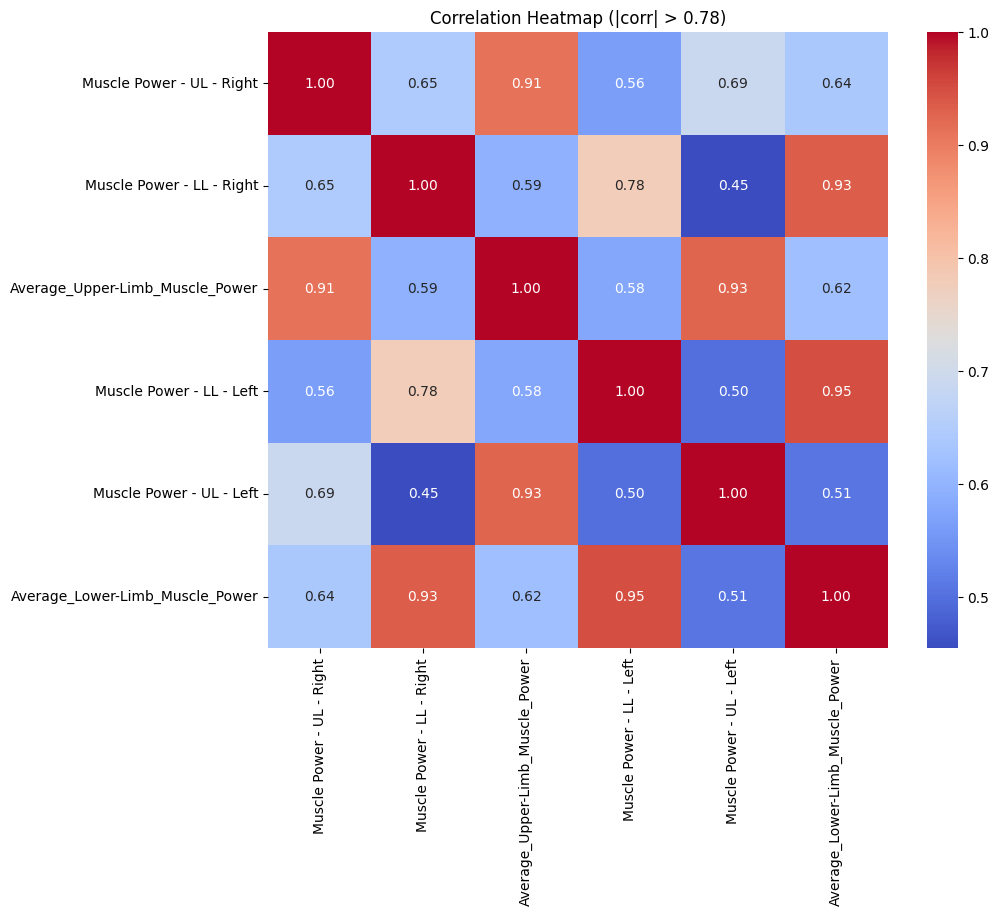

In [ ]:
# CORRELATION (TRAIN ONLY)
import seaborn as sns
import matplotlib.pyplot as plt

numeric_features = X_train_final.select_dtypes(include=[np.number])
corr_matrix = numeric_features.corr()

threshold = 0.78
high_corr_pairs = []
high_corr_features = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        val = corr_matrix.iloc[i, j]
        if abs(val) > threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            high_corr_pairs.append((col1, col2, val))
            high_corr_features.update([col1, col2])

print("\nHighly Correlated Feature Pairs (>|0.78|):")
if not high_corr_pairs:
    print("No pairs above threshold.")
else:
    for col1, col2, val in high_corr_pairs:
        print(f"{col1} <--> {col2} | correlation = {val:.2f}")

# Heatmap (optional)
if high_corr_features:
    high_corr_features = list(high_corr_features)
    corr_matrix_filtered = corr_matrix.loc[high_corr_features, high_corr_features]

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix_filtered, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title(f"Correlation Heatmap (|corr| > {threshold})")
    plt.show()

In [ ]:
# SAVE (data before Feature Selection)
from google.colab import drive
import os, datetime, joblib

drive.mount('/content/drive')

save_dir = f"/content/drive/MyDrive/data_after_corr_{datetime.datetime.now().strftime('%Y%m%d_%H%M')}"
os.makedirs(save_dir, exist_ok=True)

joblib.dump(X_train_final, os.path.join(save_dir, "X_train_final.pkl"))
joblib.dump(X_test_final, os.path.join(save_dir, "X_test_final.pkl"))
joblib.dump(y_train, os.path.join(save_dir, "y_train.pkl"))
joblib.dump(y_test, os.path.join(save_dir, "y_test.pkl"))

print("Saved to:", save_dir)

Mounted at /content/drive
Saved to: /content/drive/MyDrive/data_after_corr_20260507_1258


In [ ]:
# Manual drop redundant features
print("Before drop:", X_train_final.shape)

manual_drop = [
    'Muscle Power - LL - Right',
    'Muscle Power - UL - Right',
    'Muscle Power - UL - Left',
    'Muscle Power - LL - Left',
    'Average_Lower-Limb_Muscle_Power',
    'Average_Upper-Limb_Muscle_Power'
]

X_train_fs = X_train_final.drop(columns=manual_drop, errors='ignore')
X_test_fs  = X_test_final.drop(columns=manual_drop, errors='ignore')

print("After drop:", X_train_fs.shape)

Before drop: (264, 42)
After drop: (264, 36)


In [ ]:
# Prepare Data for Feature Selection
import numpy as np

feature_names = X_train_fs.columns.tolist()

y_train_fs = y_train

In [ ]:
# FEATURE SELECTION

import numpy as np
import pandas as pd

from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif, RFE
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# SETTINGS
SEED = 42
K = 15

results = {}
importance_tables = {}

feature_names = X_train_fs.columns.tolist()

# SCALE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_fs)

# -------------------------
# ANOVA (FULL RANKING)
# -------------------------
anova = SelectKBest(score_func=f_classif, k="all")
anova.fit(X_train_scaled, y_train_fs)

anova_scores = pd.Series(anova.scores_, index=feature_names)
results['ANOVA'] = anova_scores.sort_values(ascending=False).head(K).index.tolist()


# -------------------------
# Mutual Information (FULL RANKING)
# -------------------------
mi = SelectKBest(
    score_func=lambda X, y: mutual_info_classif(
        X, y,
        random_state=SEED
    ),
    k="all"
)
mi.fit(X_train_scaled, y_train_fs)

mi_scores = pd.Series(mi.scores_, index=feature_names)
results['Mutual_Info'] = mi_scores.sort_values(ascending=False).head(K).index.tolist()


# -------------------------
# RFE - Logistic Regression (FULL RANKING)
# -------------------------
lr = LogisticRegression(max_iter=5000)

rfe_lr = RFE(estimator=lr, n_features_to_select=1)  # allow full ranking
rfe_lr.fit(X_train_scaled, y_train_fs)

rfe_lr_rank = pd.Series(rfe_lr.ranking_, index=feature_names)
results['RFE_LR'] = rfe_lr_rank.sort_values().head(K).index.tolist()


# -------------------------
# RFE - SVM (FULL RANKING)
# -------------------------
svm = LinearSVC(max_iter=5000)

rfe_svm = RFE(estimator=svm, n_features_to_select=1)
rfe_svm.fit(X_train_scaled, y_train_fs)

rfe_svm_rank = pd.Series(rfe_svm.ranking_, index=feature_names)
results['RFE_SVM'] = rfe_svm_rank.sort_values().head(K).index.tolist()


# -------------------------
# LASSO (FULL RANKING)
# -------------------------
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=5000,
        random_state=SEED
    ))
])

lasso_pipe.fit(X_train_fs, y_train_fs)

lasso_model = lasso_pipe.named_steps['model']

lasso_coef = lasso_model.coef_
lasso_scores = np.abs(lasso_coef).sum(axis=0)

lasso_series = pd.Series(lasso_scores, index=feature_names)

results['LASSO'] = lasso_series.sort_values(ascending=False).head(K).index.tolist()


# -------------------------
# Random Forest Feature Importance (FULL RANKING)
# -------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=SEED,
    n_jobs=-1
)

rf.fit(X_train_fs, y_train_fs)

rf_scores = pd.Series(rf.feature_importances_, index=feature_names)

results['RF'] = rf_scores.sort_values(ascending=False).head(K).index.tolist()


# -------------------------
# OUTPUT
# -------------------------
print("\n=== FEATURE SELECTION RESULTS (TOP 15 FINAL) ===")
for m, f in results.items():
    print(f"\n{m}: {len(f)}")
    print(f)


=== FEATURE SELECTION RESULTS (TOP 15 FINAL) ===

ANOVA: 15
['RISK  - Risk Type', 'Target HR (bpm)', 'Test Today - METS', 'Functional Activity', 'Risk Factor - ECHO - EF', 'Age', 'Smoking', 'Family History', 'Risk Factor - Family hx', 'Gait', 'Exercise Habit - Duration', 'Occupation', 'Balance in Sitting and Standing', 'Test Today - Termination Cause', 'Exercise Habit - Frequency']

Mutual_Info: 15
['RISK  - Risk Type', 'Target HR (bpm)', 'Risk Factor - ECHO - EF', 'Posture', 'Gender', 'ECG Resting', 'Family History', 'Year', 'Cooling Down', 'Test Today - METS', 'Risk Factor - Stress', 'Risk Factor - Exercise', 'Smoking', 'Risk Factor - Family hx', 'Balance in Sitting and Standing']

RFE_LR: 15
['RISK  - Risk Type', 'Exercise Habit - Frequency', 'Exercise Habit - Mode', 'Walking', 'Diagnosis', 'Gait', 'Risk Factor - DM', 'Total_Muscle_Power', 'Smoking', 'Functional Activity', 'Posture', 'ROM', 'Test Today - METS', 'Marital Status', 'Risk Factor - ECHO - EF']

RFE_SVM: 15
['RISK  - Ris

In [ ]:
# CREATE RANK TABLE (ONLY SELECTED FEATURES)
import pandas as pd
import numpy as np
K = 15
rank_dict = results.copy()

# Ensure strict top-15 enforcement (safety check)
for method in rank_dict:
    rank_dict[method] = rank_dict[method][:K]

max_len = K

for key in rank_dict:
    rank_dict[key] += ['—'] * (max_len - len(rank_dict[key]))

rank_table = pd.DataFrame(rank_dict)
rank_table.insert(0, 'Rank', range(1, max_len + 1))

print("\n=== CONSISTENT FEATURE RANK TABLE (TOP 15 ONLY) ===")
print(rank_table)


=== CONSISTENT FEATURE RANK TABLE (TOP 15 ONLY) ===
    Rank                            ANOVA                      Mutual_Info  \
0      1                RISK  - Risk Type                RISK  - Risk Type   
1      2                  Target HR (bpm)                  Target HR (bpm)   
2      3                Test Today - METS          Risk Factor - ECHO - EF   
3      4              Functional Activity                          Posture   
4      5          Risk Factor - ECHO - EF                           Gender   
5      6                              Age                      ECG Resting   
6      7                          Smoking                   Family History   
7      8                   Family History                             Year   
8      9          Risk Factor - Family hx                     Cooling Down   
9     10                             Gait                Test Today - METS   
10    11        Exercise Habit - Duration             Risk Factor - Stress   
11    12   

In [ ]:
# Save Feature Selection Output
import joblib, os, datetime
from google.colab import drive
drive.mount('/content/drive')

save_dir = f"/content/drive/MyDrive/FS_results_{datetime.datetime.now().strftime('%Y%m%d_%H%M')}"
os.makedirs(save_dir, exist_ok=True)

for method, feats in results.items():
    joblib.dump(feats, os.path.join(save_dir, f"{method}.pkl"))

print("All feature sets saved.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All feature sets saved.



=== Number of Features Selected by Each Method ===
ANOVA: 15 features
Mutual_Info: 15 features
RFE_LR: 15 features
RFE_SVM: 15 features
LASSO: 15 features
RF: 15 features


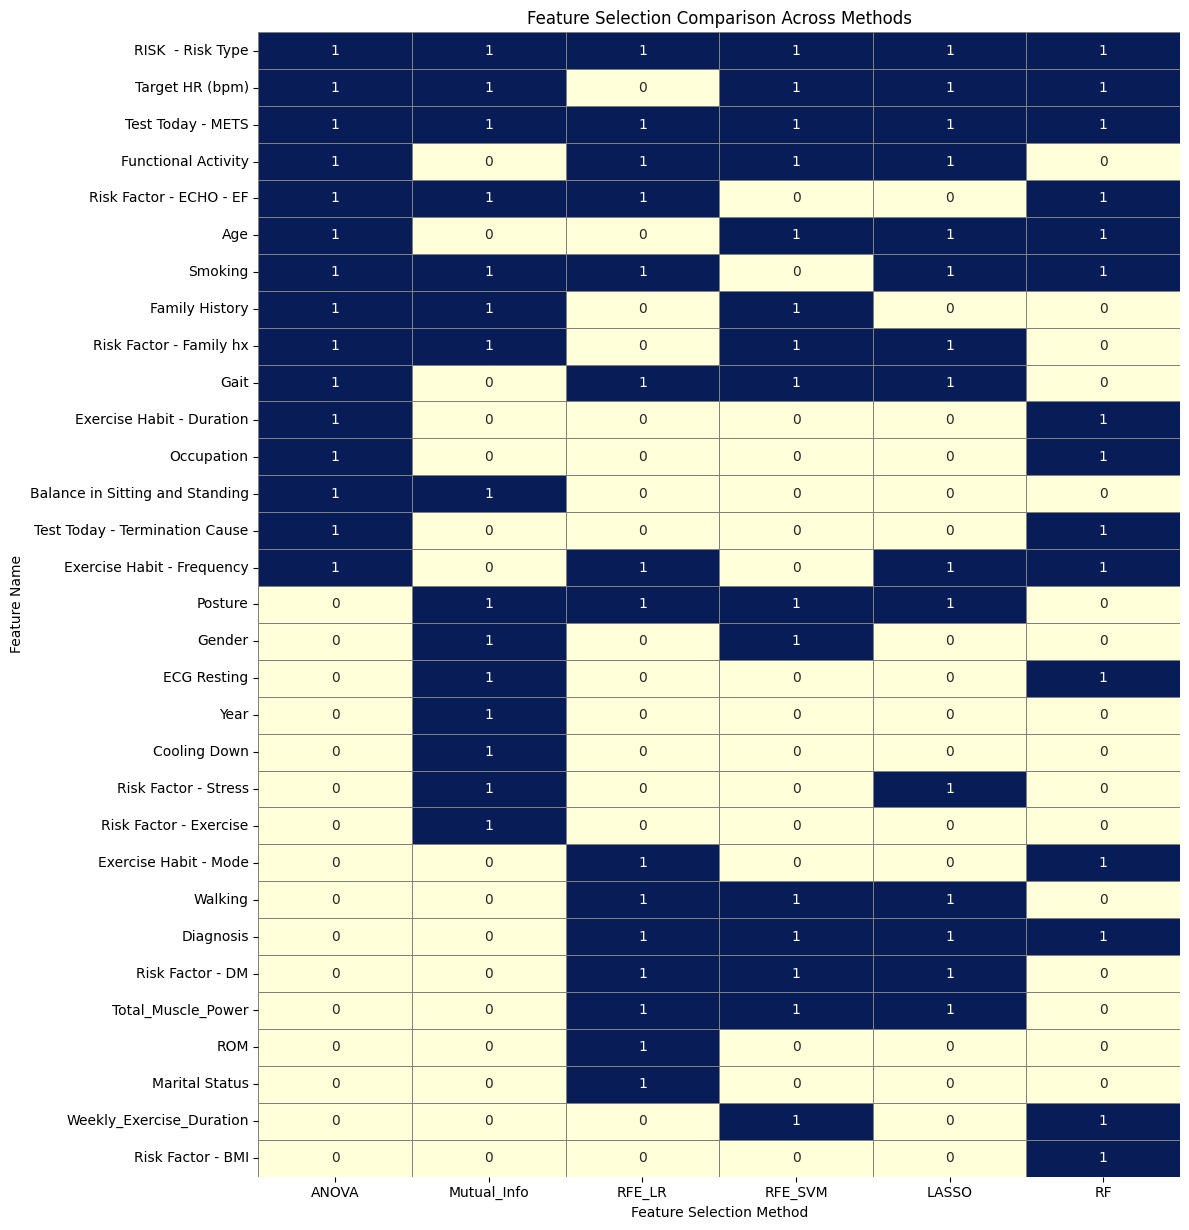

In [ ]:
# Heatmap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use results directly (IMPORTANT FIX)
method_features = {
    method: list(features)
    for method, features in results.items()
}

# Combine all features across methods
all_features = []
for feats in method_features.values():
    all_features.extend(feats)

all_features = list(dict.fromkeys(all_features))  # preserves order, removes duplicates

# Create binary matrix
feature_matrix = pd.DataFrame(
    {
        method: [1 if f in features else 0 for f in all_features]
        for method, features in method_features.items()
    },
    index=all_features
)

# Print summary
print("\n=== Number of Features Selected by Each Method ===")
for method, features in results.items():
    print(f"{method}: {len(features)} features")

# Plot heatmap
plt.figure(figsize=(12, len(all_features) * 0.4))

sns.heatmap(
    feature_matrix,
    annot=True,
    cmap='YlGnBu',
    cbar=False,
    linewidths=0.5,
    linecolor='gray'
)

plt.title('Feature Selection Comparison Across Methods')
plt.xlabel('Feature Selection Method')
plt.ylabel('Feature Name')

plt.tight_layout()
plt.show()

In [ ]:
# FEATURE CONSENSUS ANALYSIS
from collections import Counter

# Flatten all selected features
all_selected = []
for feats in results.values():
    all_selected.extend(set(feats))

# Count how many methods selected each feature
feature_counts = Counter(all_selected)

# Convert to DataFrame
consensus_df = pd.DataFrame.from_dict(
    feature_counts, orient='index', columns=['Count']
).sort_values(by='Count', ascending=False)

print("\n=== FEATURE SELECTION FREQUENCY ===")
print(consensus_df)

# GROUP FEATURES BY NUMBER OF METHODS

grouped_features = {}

for k in range(len(results), 0, -1):  # 7 → 1
    grouped_features[k] = consensus_df[consensus_df['Count'] == k].index.tolist()

# Print nicely
print("\n=== FEATURE CONSENSUS GROUPS ===")
for k, feats in grouped_features.items():
    print(f"\nSelected by {k} methods ({len(feats)} features):")
    print(feats)


=== FEATURE SELECTION FREQUENCY ===
                                 Count
RISK  - Risk Type                    6
Test Today - METS                    6
Target HR (bpm)                      5
Smoking                              5
Functional Activity                  4
Exercise Habit - Frequency           4
Gait                                 4
Risk Factor - ECHO - EF              4
Age                                  4
Risk Factor - Family hx              4
Posture                              4
Diagnosis                            4
Walking                              3
Total_Muscle_Power                   3
Family History                       3
Risk Factor - DM                     3
Balance in Sitting and Standing      2
Exercise Habit - Duration            2
Test Today - Termination Cause       2
Occupation                           2
ECG Resting                          2
Gender                               2
Risk Factor - Stress                 2
Weekly_Exercise_Duration   